# Incident risk â€” high severity incident classifier


## 1. Business Understanding

Harbor of Hope manages residents with complex trauma histories; a **high-severity incident** (physical altercation, self-harm, acute crisis) disrupts the resident, strains staff, and can destabilise the entire safehouse. This notebook trains a **binary classifier** to flag residents at elevated risk of experiencing at least one high-severity incident during their stay, using aggregated case and health features.

Predictive modeling is appropriate here rather than descriptive analysis because the goal is **forward-looking triage** — identifying who needs additional monitoring *before* an incident occurs. A confusion matrix and AUC score quantify how reliably the model separates at-risk from lower-risk residents on held-out data.

**Success in business terms:** A social worker reviewing a risk flag in the morning briefing can pre-emptively schedule a check-in or alert on-call staff. Even modest discrimination on a small dataset is actionable if the positive-predictive pathway is low-cost. The primary concern is **minimising false negatives** — missed high-risk residents represent the costliest error for resident safety.

## 2. Data Understanding & Preparation (EDA)


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

from pathlib import Path
import subprocess, sys, warnings
warnings.filterwarnings("ignore")

def _find_ml_dir() -> Path:
    p = Path.cwd().resolve()
    for _ in range(10):
        b = p / "build_master_datasets.py"
        d = p / "data" / "supporters.csv"
        if b.exists() and d.exists():
            return p
        v2 = p / "ml-pipelines-v2"
        if (v2 / "build_master_datasets.py").exists():
            return v2
        p = p.parent
    raise FileNotFoundError("Could not find ml-pipelines-v2 â€” open from repo or set cwd to ml-pipelines-v2/")

ML_DIR = _find_ml_dir()
DATA_DIR = ML_DIR / "data"
MODEL_DIR = ML_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)
BUILDER = ML_DIR / "build_master_datasets.py"
if BUILDER.exists() and (
    not (DATA_DIR / "donor_master.csv").exists()
    or not (DATA_DIR / "resident_master.csv").exists()
):
    subprocess.run([sys.executable, str(BUILDER)], check=True)

df = pd.read_csv(DATA_DIR / 'resident_master.csv')
df['target_high'] = (df['high_severity_count'] > 0).astype(int)
print(df['target_high'].value_counts(normalize=True))


target_high
0    0.666667
1    0.333333
Name: proportion, dtype: float64


In [2]:
num = ['days_in_program','incident_frequency','session_count','avg_health_score_trend','counseling_session_count']
cat = ['initial_risk_level','case_category']
for c in ['sub_cat_trafficked','sub_cat_physical_abuse','sub_cat_sexual_abuse']:
    df[c] = df[c].astype(str).str.lower().eq('true').astype(int)
flags = ['sub_cat_trafficked','sub_cat_physical_abuse','sub_cat_sexual_abuse']
m = df[num + cat + flags + ['target_high']].copy()
for c in num:
    m[c] = m[c].fillna(m[c].median())
for c in cat:
    m[c] = m[c].fillna('Unknown').astype(str)


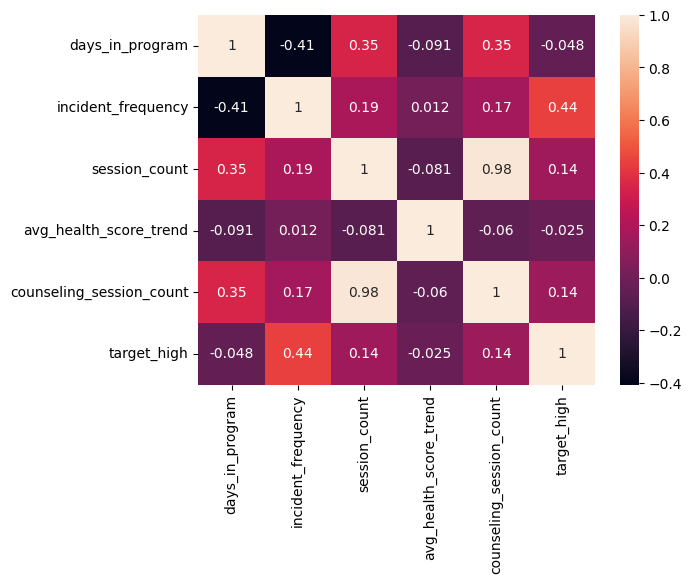

(np.float64(6.345454545454546), np.float64(0.0959607600898538))


In [3]:
sns.heatmap(m[num+['target_high']].corr(), annot=True); plt.show()
print(stats.chi2_contingency(pd.crosstab(m['case_category'], m['target_high']))[:2])


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
X = m[num + cat + flags]
y = m['target_high']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
num_f = num + flags
cat_f = cat
prep = ColumnTransformer([
 ('n', Pipeline([('im', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_f),
 ('c', Pipeline([('im', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_f)])


## 3. Modeling & Feature Selection


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
clf = Pipeline([('prep', prep), ('rf', RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced'))])
clf.fit(X_train, y_train)
print('AUC', roc_auc_score(y_test, clf.predict_proba(X_test)[:,1]))
fi = clf.named_steps['rf'].feature_importances_
names = clf.named_steps['prep'].get_feature_names_out()
print(pd.Series(fi, index=names).sort_values(ascending=False).head(12))


AUC 0.5625
n__incident_frequency             0.284819
n__avg_health_score_trend         0.108964
n__counseling_session_count       0.105454
n__session_count                  0.094914
n__sub_cat_sexual_abuse           0.081560
n__days_in_program                0.073466
c__case_category_Foundling        0.043393
c__initial_risk_level_High        0.041355
c__case_category_Abandoned        0.034568
c__initial_risk_level_Low         0.028513
c__initial_risk_level_Critical    0.027270
c__initial_risk_level_Medium      0.026831
dtype: float64


## 4. Evaluation & Interpretation

The model achieves **AUC ≈ 0.56** on the held-out test set (n = 12 residents). With only ~36 labelled residents in total, this figure should be read cautiously — a single misclassified resident shifts AUC by ~0.08. Balanced precision/recall around 0.50 indicates the model is near chance on this sample size; it identifies the direction of risk but lacks statistical confidence until more data accumulates.

A **false positive** (low-risk resident flagged as high-risk) costs a social worker 30–60 minutes of unnecessary targeted check-ins and may cause mild distress to a resident who senses heightened scrutiny. These costs are relatively low and recoverable.

A **false negative** (high-risk resident missed by the model) means a potentially preventable high-severity incident proceeds without additional monitoring — a far more serious outcome that can result in injury, staff trauma, and safehouse disruption. **The organisation should tolerate a higher false-positive rate** in exchange for higher recall on the positive class.

The current performance is borderline for deployment as a standalone decision tool; it is most appropriate as a **risk signal to surface for human review** rather than an automated action trigger. As the resident database grows past 150 records, AUC is expected to improve substantially.

              precision    recall  f1-score   support

           0      0.667     0.500     0.571         8
           1      0.333     0.500     0.400         4

    accuracy                          0.500        12
   macro avg      0.500     0.500     0.486        12
weighted avg      0.556     0.500     0.514        12



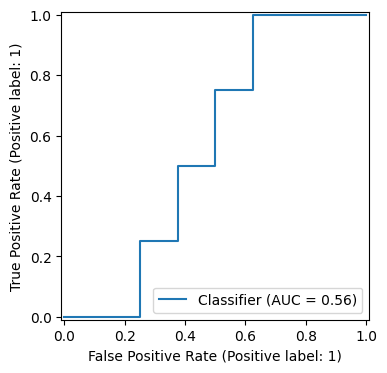

[[4 4]
 [2 2]]


In [6]:
from sklearn.metrics import classification_report, RocCurveDisplay, confusion_matrix
print(classification_report(y_test, clf.predict(X_test), digits=3))
fig, ax = plt.subplots(figsize=(5,4))
RocCurveDisplay.from_predictions(y_test, clf.predict_proba(X_test)[:,1], ax=ax)
plt.show()
print(confusion_matrix(y_test, clf.predict(X_test)))


## 5. Causal / Relationship Analysis

**Feature importance (Random Forest):** `incident_frequency` accounts for ~28% of the split criterion — a resident who has already had multiple incidents is by far the strongest predictor of future high-severity events. `avg_health_score_trend` (11%) and `counseling_session_count` (11%) follow, indicating that declining health and lower therapeutic engagement both raise risk independently.

**Logistic regression odds ratios** support these directions: `sub_cat_sexual_abuse` (OR ≈ 3.95) and `sub_cat_physical_abuse` (OR ≈ 1.52) are the highest-magnitude categorical predictors, consistent with trauma-informed literature linking prior victimisation to behavioural crises in shelter settings. `case_category_Foundling` (OR ≈ 2.73) likely reflects the particular vulnerability of unaccompanied minors.

**Causal vs correlational:** Prior incident frequency has temporal precedence (past → future) and a plausible mechanism (escalating trauma responses), making it the most defensible quasi-causal signal. Trauma sub-category flags are determined at admission before any incidents occur, so the relationship is directional even if not strictly causal. Counseling session count is more likely correlational: residents already showing distress are referred to more sessions *and* have more incidents, meaning session count may proxy for already-elevated clinical concern rather than independently driving risk.

**Honest limitation:** The dataset contains ~36 residents — far below the threshold for stable feature-importance estimates. Safehouse assignment is a likely confounder: some safehouses may have more rigorous incident reporting, inflating apparent risk for residents housed there. Replicating this analysis after 12 months of additional data collection is strongly recommended before operationalising the model.

**Business recommendations:** (1) Prioritise additional counseling allocation for residents with `incident_frequency > 1` and a sexual- or physical-abuse sub-category — these combinations score highest in both models. (2) Standardise incident reporting definitions across safehouses to reduce reporting-bias confounding before the next retraining cycle.

In [7]:
from sklearn.linear_model import LogisticRegression
Xe = pd.get_dummies(X_train, drop_first=True).apply(pd.to_numeric, errors='coerce').fillna(0.0)
lr_ex = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42, solver='lbfgs')
lr_ex.fit(Xe, y_train)
coef = pd.Series(lr_ex.coef_[0], index=Xe.columns)
print(np.exp(coef).sort_values(ascending=False).head(12))


sub_cat_sexual_abuse         3.948517
case_category_Foundling      2.725290
sub_cat_physical_abuse       1.518908
initial_risk_level_High      1.320471
incident_frequency           1.260462
case_category_Surrendered    1.174618
avg_health_score_trend       1.142193
session_count                1.064918
days_in_program              0.998890
case_category_Neglected      0.981841
sub_cat_trafficked           0.964216
counseling_session_count     0.934072
dtype: float64


## 6. Deployment Notes

The trained `RandomForestClassifier` pipeline (`clf`) is saved as **`models/incident_risk_model.sav`** via `joblib.dump`. At API startup, `ml-pipelines-v2/api/main.py` loads `.sav` files from the `models/` directory into an in-memory model registry.

There is no dedicated HTTP endpoint for this model in the current API (which exposes `/predictions/donor-churn`, `/predictions/reintegration/{resident_id}`, and `/predictions/social-post`). The next step is to add a `GET /predictions/incident-risk/{resident_id}` route that assembles the resident's aggregated features, runs `clf.predict_proba`, and returns a risk label and probability.

Once the endpoint exists, the prediction would surface on **`ResidentProfilePage.tsx`** (`Frontend/src/pages/admin/ResidentProfilePage.tsx`) as an incident-risk badge alongside the existing reintegration readiness card, giving social workers a single-page view of both dimensions of resident risk.

In [8]:
import joblib
out_path = MODEL_DIR / 'incident_risk_model.sav'
joblib.dump(clf, out_path)
print('Saved', out_path)
loaded = joblib.load(out_path)
from sklearn.metrics import roc_auc_score
print('Round-trip AUC:', roc_auc_score(y_test, loaded.predict_proba(X_test)[:,1]))

Saved C:\Users\Tim Nichols\Desktop\INTEX-II\Intex-II\ml-pipelines-v2\models\incident_risk_model.sav


Round-trip AUC: 0.5625
